Esercizio
Il rumore è il nemico numero uno di Canny. Spesso , un filtraggio gaussiano manuale pre-Canny produce risultati migliori di quello integrato.
Carica un'immagine e applica un Blur Gaussiano con kernel 7x7
Sfida: crea un ciclo che testi tre diverse soglie massime (150, 200, 250) mantenendo la soglia minima fissa a 50.  Visualizza come cambia la connettività dei bordi (isteresi)

[*] Download immagine da: https://picsum.photos/id/102/800/600


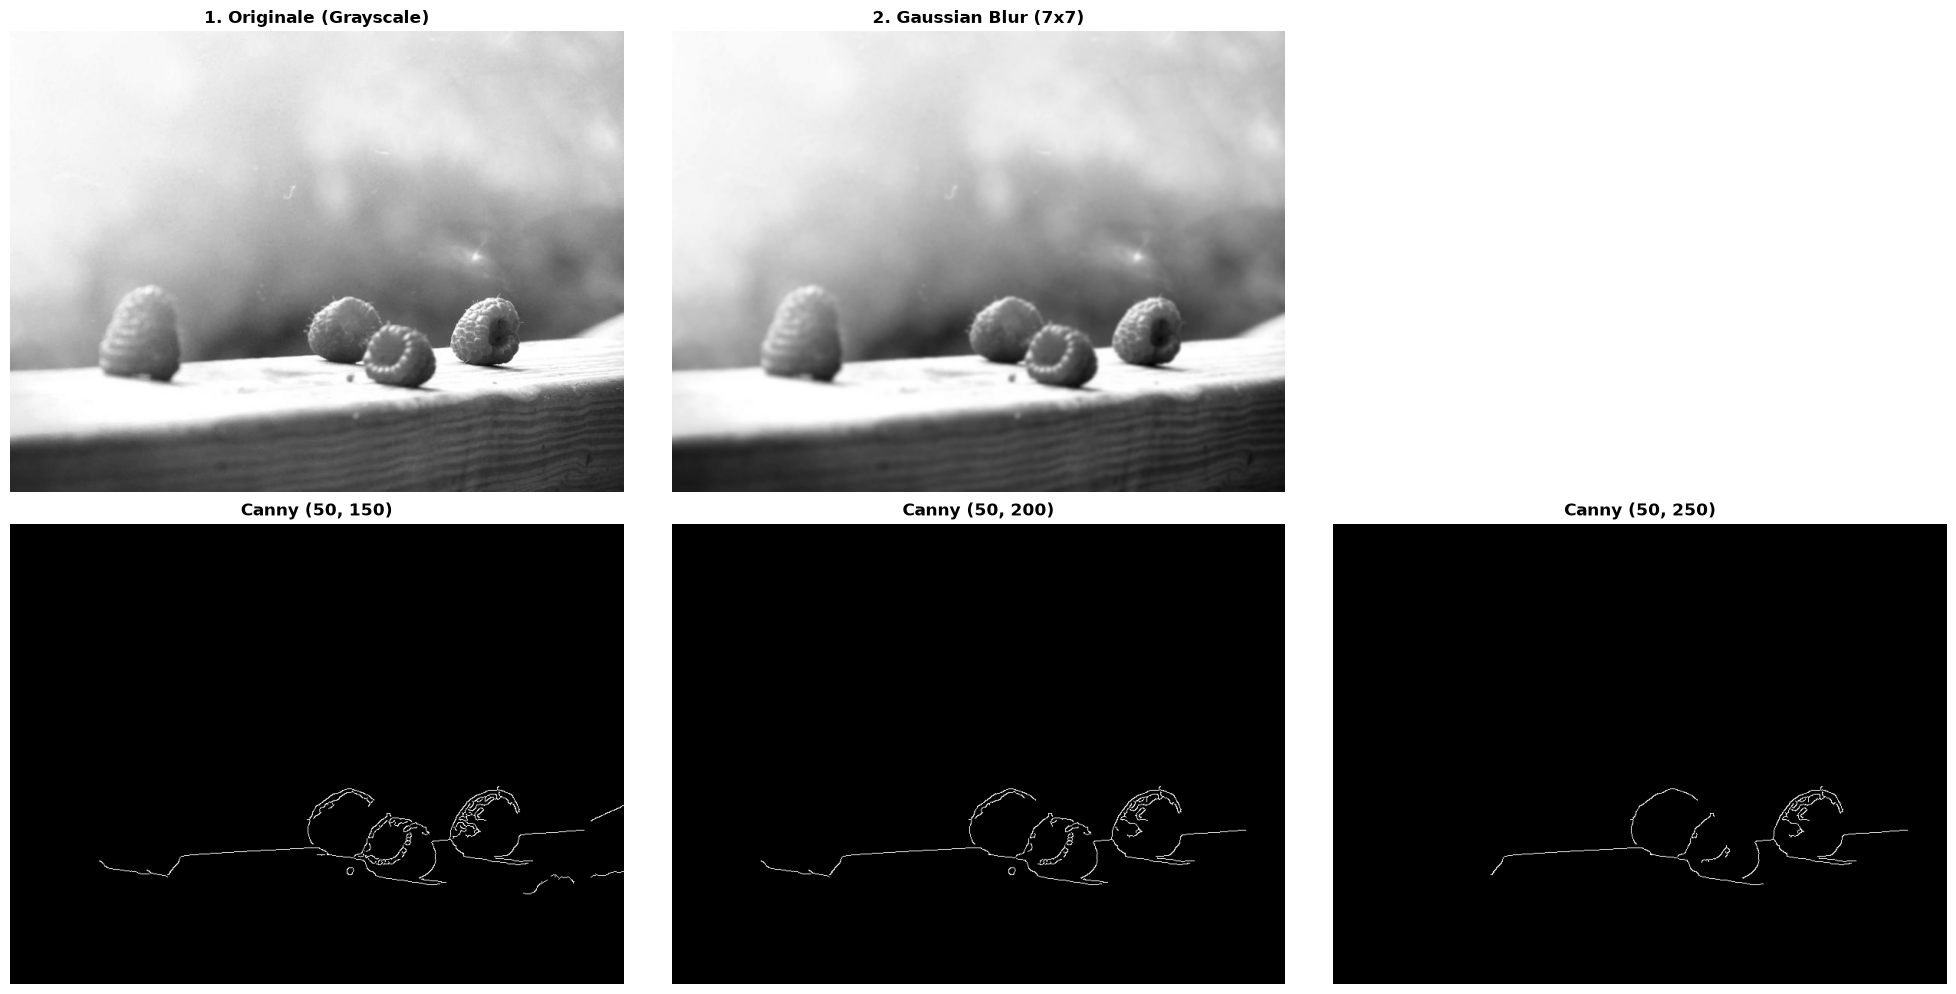

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from pathlib import Path

# Configurazione Best Practice
os.environ["KERAS_BACKEND"] = "torch"

def test_canny_hysteresis(url: str):
    """
    Scarica un'immagine, applica un blur manuale e testa diverse soglie di Canny
    per analizzare la connettività dei bordi.
    """
    # 1. CARICAMENTO DA INTERNET
    print(f"[*] Download immagine da: {url}")
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        image_array = np.frombuffer(response.content, np.uint8)
        img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError("Errore nella decodifica.")
    except Exception as e:
        print(f"[-] Errore: {e}")
        return

    # 2. RIDUZIONE DEL RUMORE (MANUALE)
    # Applichiamo un Blur Gaussiano 7x7. Più grande è il kernel, 
    # più l'immagine diventa "morbida", eliminando i dettagli insignificanti.
    img_blurred = cv2.GaussianBlur(img, (7, 7), 0)

    # 3. SFIDA: TEST DELLE SOGLIE DI ISTERESI
    low_threshold = 50
    high_thresholds = [150, 200, 250]
    results = []

    for high in high_thresholds:
        # Canny applicato sull'immagine già blurrata manualmente
        edges = cv2.Canny(img_blurred, low_threshold, high)
        results.append(edges)

    # 4. VISUALIZZAZIONE COMPARATIVA
    plt.figure(figsize=(20, 10))
    
    # Immagine Originale vs Blurred
    plt.subplot(2, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("1. Originale (Grayscale)", fontweight='bold')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(img_blurred, cmap='gray')
    plt.title("2. Gaussian Blur (7x7)", fontweight='bold')
    plt.axis('off')

    # Risultati Canny
    for i, edges in enumerate(results):
        plt.subplot(2, 3, 4 + i)
        plt.imshow(edges, cmap='gray')
        plt.title(f"Canny (50, {high_thresholds[i]})", fontweight='bold')
        plt.axis('off')
        
        # Aumentando la soglia massima,  i bordi diventano più "frammentati" o spariscono del tutto.
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Utilizziamo un'immagine con dettagli complessi per vedere l'effetto del rumore
    test_url = "https://picsum.photos/id/102/800/600"
    test_canny_hysteresis(test_url)